# Box plot of evaluation values



In [2]:
# load packages
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

/home/ashc/miniforge3/envs/thesis-rl/lib/python3.10/site-packages/gym/envs/registration.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
while not os.getcwd().endswith("GGSpeciale"):
    os.chdir("..")
os.chdir("code/SPID_code/")
from PySRWrapper_safe import PySRPolicy
from gmDAGGER import train_spid

while not os.getcwd().endswith("GGSpeciale"):
    os.chdir("..")
os.chdir("Simglucose_suite/")
from evaluate import evaluate_insulin_policy
os.getcwd()

/home/ashc/miniforge3/envs/thesis-rl/lib/python3.10/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/home/ashc/miniforge3/envs/thesis-rl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'/faststorage/project/GGSpeciale/GGSpeciale/Simglucose_suite'

In [4]:
# Get teacher values; collect dataframe for each teacher model

folder_path = Path("./models/closed_hist_optuna_optimal_2")
#folder_path = Path("./models/open_optuna_optimal")
metrics_file = "logs/eval/eval_log/metrics_log.csv"


scores = []

for folder_reward in folder_path.iterdir():

    if folder_reward.name == "clarke_risk":

        for folder in folder_reward.iterdir():

            if folder.is_dir():        
                file_path = folder / metrics_file

                if file_path.exists():
                    
                    print(f"loading {folder.name}")
                    patient_scores_path = {"patient" : folder.name}
                    patient_scores= pd.read_csv(file_path)

                    best = patient_scores.iloc[patient_scores["mean_reward"].idxmax()]
                    timestep = best["num_timesteps"]

                    scores.append({"reward_type" : folder_reward.name, "patient" : folder.name} | dict(best))


ppo_scores = pd.DataFrame(scores)

loading adult-001
loading adult-006
loading adult-008
loading adult-002
loading adult-005
loading adult-007
loading adult-004
loading adult-003
loading adult-009
loading adult-010


In [5]:
ppo_scores.head()

,reward_type,patient,eval_index,TBR_II,TBR_I,TIR,TAR_I,TAR_II,total_daily_insulin,average_insulin,...,critical_failure_rate_ci95_upper,critical_failure_count,completed_episode_count,survivors,num_timesteps,mean_reward,std_reward,reward_ti90_95_lower,reward_ti90_95_upper,n_eval_episodes
0,clarke_risk,adult-001,0.0,0.357914,3.258734,88.781542,7.959724,0.016306,0.0,NaN,...,19.551644,45.0,255.0,255.0,NaN,417.015267,63.033702,285.314758,461.447235,300.0
1,clarke_risk,adult-006,0.0,0.991159,5.478648,74.145473,20.375879,0.665919,0.0,NaN,...,38.292229,98.0,202.0,202.0,NaN,372.587537,62.653739,206.706696,425.757202,300.0
2,clarke_risk,adult-008,0.0,0.275116,1.383396,98.487643,0.128961,0.000000,0.0,NaN,...,15.475954,34.0,266.0,266.0,NaN,439.822370,82.003964,133.879105,474.521820,300.0
3,clarke_risk,adult-002,0.0,0.181821,4.000805,88.721143,7.278052,0.000000,0.0,NaN,...,10.501400,21.0,279.0,279.0,NaN,426.222950,50.225769,313.770416,463.188202,300.0
4,clarke_risk,adult-005,0.0,0.343386,2.479229,89.051368,8.469403,0.000000,0.0,NaN,...,15.100322,33.0,267.0,267.0,NaN,406.589394,100.200328,78.948898,463.057800,300.0


In [6]:
# Get symbolic performances 


baseline_path = Path("./distilled_final_5/closed")
metrics_file = "distilled_eval/eval_log/metrics_log.csv"

scores = pd.DataFrame()
best_scores = pd.DataFrame()

for model_type in  baseline_path.iterdir():

    for patient in model_type.iterdir():

        if patient.is_dir():  

            for run_test in patient.iterdir():       
                file_path =  run_test / "clarke_risk" / patient.name / metrics_file

                pysr_policy_path = run_test / "clarke_risk" / patient.name / "best_student_policy.joblib"

                if file_path.exists():
            
                    patient_scores = pd.read_csv(file_path) #.tail(1)
                    patient_scores["patient"] = patient.name
                    patient_scores["run_nr"] = run_test.name
                    patient_scores["model_type"] = model_type.name
                    patient_scores["path"] = file_path

                    pysr_policy = PySRPolicy.load(pysr_policy_path)
                    patient_scores["model"] = pysr_policy
                    patient_scores["equation"] = "$" + pysr_policy.policy_list[0].sr.latex() + "$"
                    patient_scores["complexity"] = pysr_policy.policy_list[0].sr.get_best()["complexity"]

                    scores = pd.concat([scores, patient_scores])

#scores[display_columns].sort_values(by="patient_name")
scores = scores.set_index(["patient", "model_type"]).dropna(subset="TIR")
symbolic_policy_scores= scores[scores["mean_reward"].eq(scores.groupby(level=0)["mean_reward"].transform("max"))].reset_index().sort_values(by="patient")

Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded


In [7]:
scores.head()

eval_index    TBR_II      TBR_I        TIR     TAR_I  \
patient   model_type                                                         
adult-001 linear_10            0  0.372323   2.340656  97.249077  0.410267   
          linear_10            0  8.699168  23.879390  76.120610  0.000000   
          linear_10            0  0.572357   2.782664  91.092276  6.125060   
          linear_10            0  0.668186   3.340021  94.322236  2.337743   
          linear_10            0  0.742393   3.422813  95.107535  1.469651   

                      TAR_II  total_daily_insulin  average_insulin  \
patient   model_type                                                 
adult-001 linear_10      0.0                  0.0              NaN   
          linear_10      0.0                  0.0              NaN   
          linear_10      0.0                  0.0              NaN   
          linear_10      0.0                  0.0              NaN   
          linear_10      0.0                  0.0              NaN   

                      TBR_II_episode_mean  TBR_II_episode_std  ...  \
patient   model_type                                           ...   
adult-001 linear_10              0.372323            1.790430  ...   
          linear_10              8.698795            4.191598  ...   
          linear_10              0.572357            1.705858  ...   
          linear_10              0.668186            1.815698  ...   
          linear_10              0.742389            1.998769  ...   

                      mean_reward  std_reward  reward_ti90_95_lower  \
patient   model_type                                                  
adult-001 linear_10    446.375016   43.553406            332.067688   
          linear_10    165.420293  113.138530             67.611000   
          linear_10    417.051259   56.292602            284.599518   
          linear_10    416.893188   63.916555            272.522034   
          linear_10    438.041199   44.451589            316.759644   

                      reward_ti90_95_upper  n_eval_episodes  run_nr  \
patient   model_type                                                  
adult-001 linear_10             473.514801              300  run_02   
          linear_10             410.325623              300  run_01   
          linear_10             468.312042              300  run_04   
          linear_10             471.268677              300  run_03   
          linear_10             471.733704              300  run_00   

                                                                   path  \
patient   model_type                                                      
adult-001 linear_10   distilled_final_5/closed/linear_10/adult-001/r...   
          linear_10   distilled_final_5/closed/linear_10/adult-001/r...   
          linear_10   distilled_final_5/closed/linear_10/adult-001/r...   
          linear_10   distilled_final_5/closed/linear_10/adult-001/r...   
          linear_10   distilled_final_5/closed/linear_10/adult-001/r...   

                                                                  model  \
patient   model_type                                                      
adult-001 linear_10   <PySRWrapper_safe.PySRPolicy object at 0x7fd5b...   
          linear_10   <PySRWrapper_safe.PySRPolicy object at 0x7fd5b...   
          linear_10   <PySRWrapper_safe.PySRPolicy object at 0x7fd76...   
          linear_10   <PySRWrapper_safe.PySRPolicy object at 0x7fd5b...   
          linear_10   <PySRWrapper_safe.PySRPolicy object at 0x7fd5b...   

                                                               equation  \
patient   model_type                                                      
adult-001 linear_10                                 $x_{0} \cdot 0.155$   
          linear_10   $\left(x_{0} - 0.228\right) \left(x_{6} - -1.1...   
          linear_10                  $x_{0} \left(x_{0} - 0.216\right)$   
          linear_10                  $x_{0} \left(x_{0} - 0.189\right)

In [8]:
symbolic_policy_scores.head()

,patient,model_type,eval_index,TBR_II,TBR_I,TIR,TAR_I,TAR_II,total_daily_insulin,average_insulin,...,mean_reward,std_reward,reward_ti90_95_lower,reward_ti90_95_upper,n_eval_episodes,run_nr,path,model,equation,complexity
0,adult-001,linear_10,0,0.372323,2.340656,97.249077,0.410267,0.000000,0.0,NaN,...,446.375016,43.553406,332.067688,473.514801,300,run_02,distilled_final_5/closed/linear_10/adult-001/r...,<PySRWrapper_safe.PySRPolicy object at 0x7fd5b...,$x_{0} \cdot 0.155$,3
3,adult-002,linear_10,0,0.021507,2.788750,89.714601,7.496648,0.000000,0.0,NaN,...,434.399511,22.705102,392.640015,462.970917,300,run_00,distilled_final_5/closed/linear_10/adult-002/r...,<PySRWrapper_safe.PySRPolicy object at 0x7fd5b...,$x_{0} x_{0} \left(0.528 - x_{1}\right)$,7
8,adult-003,linear_10,0,0.523909,8.242827,76.270270,15.486902,1.788773,0.0,NaN,...,369.650762,88.812649,86.545685,442.125854,300,run_04,distilled_final_5/closed/linear_10/adult-003/r...,<PySRWrapper_safe.PySRPolicy object at 0x7fd5b...,$x_{0} x_{0} x_{2} x_{6}$,7
6,adult-004,linear_10,0,0.031822,1.103859,69.050936,29.845205,4.456450,0.0,NaN,...,381.298970,14.618859,361.144012,408.167267,300,run_00,distilled_final_5/closed/linear_10/adult-004/r...,<PySRWrapper_safe.PySRPolicy object at 0x7fd5b...,$x_{0} \cdot 0.133 \left(x_{0} - x_{1}\right)$,7
4,adult-005,linear_10,0,0.144041,2.091789,94.161723,3.746488,0.000000,0.0,NaN,...,437.585487,42.746254,375.130890,468.082672,300,run_04,distilled_final_5/closed/linear_10/adult-005/r...,<PySRWrapper_safe.PySRPolicy object at 0x7fd5b...,$x_{0} \cdot 0.177$,3


In [9]:
scores_df = pd.merge(ppo_scores, symbolic_policy_scores, how="inner", on="patient", suffixes=("_ppo", "_sp"))

scores_df.head()

,reward_type,patient,eval_index_ppo,TBR_II_ppo,TBR_I_ppo,TIR_ppo,TAR_I_ppo,TAR_II_ppo,total_daily_insulin_ppo,average_insulin_ppo,...,mean_reward_sp,std_reward_sp,reward_ti90_95_lower_sp,reward_ti90_95_upper_sp,n_eval_episodes_sp,run_nr,path,model,equation,complexity
0,clarke_risk,adult-001,0.0,0.357914,3.258734,88.781542,7.959724,0.016306,0.0,NaN,...,446.375016,43.553406,332.067688,473.514801,300,run_02,distilled_final_5/closed/linear_10/adult-001/r...,<PySRWrapper_safe.PySRPolicy object at 0x7fd5b...,$x_{0} \cdot 0.155$,3
1,clarke_risk,adult-006,0.0,0.991159,5.478648,74.145473,20.375879,0.665919,0.0,NaN,...,375.068319,33.062307,277.322723,411.866516,300,run_03,distilled_final_5/closed/linear_10/adult-006/r...,<PySRWrapper_safe.PySRPolicy object at 0x7fd5b...,$x_{0} \cdot 0.118$,3
2,clarke_risk,adult-008,0.0,0.275116,1.383396,98.487643,0.128961,0.000000,0.0,NaN,...,467.402092,12.699718,429.582001,475.651001,300,run_04,distilled_final_5/closed/linear_10/adult-008/r...,<PySRWrapper_safe.PySRPolicy object at 0x7fd5b...,$x_{5} \cdot 0.0953 \left(- x_{4} + x_{5}\right)$,7
3,clarke_risk,adult-002,0.0,0.181821,4.000805,88.721143,7.278052,0.000000,0.0,NaN,...,434.399511,22.705102,392.640015,462.970917,300,run_00,distilled_final_5/closed/linear_10/adult-002/r...,<PySRWrapper_safe.PySRPolicy object at 0x7fd5b...,$x_{0} x_{0} \left(0.528 - x_{1}\right)$,7
4,clarke_risk,adult-005,0.0,0.343386,2.479229,89.051368,8.469403,0.000000,0.0,NaN,...,437.585487,42.746254,375.130890,468.082672,300,run_04,distilled_final_5/closed/linear_10/adult-005/r...,<PySRWrapper_safe.PySRPolicy object at 0x7fd5b...,$x_{0} \cdot 0.177$,3


In [10]:
scores_df.columns

Index(['reward_type', 'patient', 'eval_index_ppo', 'TBR_II_ppo', 'TBR_I_ppo',
       'TIR_ppo', 'TAR_I_ppo', 'TAR_II_ppo', 'total_daily_insulin_ppo',
       'average_insulin_ppo',
       ...
       'mean_reward_sp', 'std_reward_sp', 'reward_ti90_95_lower_sp',
       'reward_ti90_95_upper_sp', 'n_eval_episodes_sp', 'run_nr', 'path',
       'model', 'equation', 'complexity'],
      dtype='object', length=106)

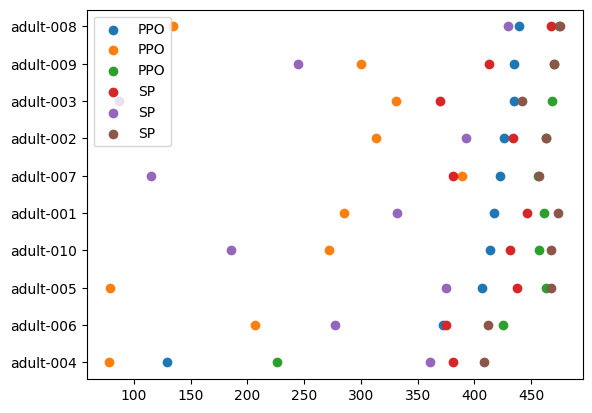

In [11]:
plot_df = scores_df.sort_values(by="mean_reward_ppo")
scores_plot_df = scores.reset_index()
plt.scatter(plot_df["mean_reward_ppo"], plot_df["patient"], label="PPO")
plt.scatter(plot_df["reward_ti90_95_lower_ppo"], plot_df["patient"], label="PPO")
plt.scatter(plot_df["reward_ti90_95_upper_ppo"], plot_df["patient"], label="PPO")

plt.scatter(plot_df["mean_reward_sp"], plot_df["patient"], label="SP")
plt.scatter(plot_df["reward_ti90_95_lower_sp"], plot_df["patient"], label="SP")
plt.scatter(plot_df["reward_ti90_95_upper_sp"], plot_df["patient"], label="SP")

plt.legend()


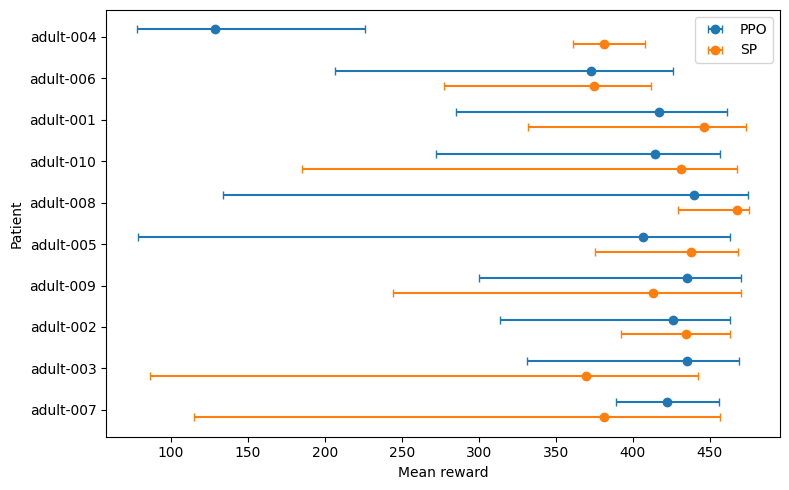

In [12]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = scores_df.sort_values(by="critical_failure_rate_ppo").reset_index(drop=True)

y = np.arange(len(plot_df))
offset = 0.18

# Means
ppo_mean = plot_df["mean_reward_ppo"]
sp_mean = plot_df["mean_reward_sp"]

# Confidence bounds converted to asymmetric errors
ppo_xerr = np.vstack([
    ppo_mean - plot_df["reward_ti90_95_lower_ppo"],
    plot_df["reward_ti90_95_upper_ppo"] - ppo_mean
])

sp_xerr = np.vstack([
    sp_mean - plot_df["reward_ti90_95_lower_sp"],
    plot_df["reward_ti90_95_upper_sp"] - sp_mean
])

plt.figure(figsize=(8, max(5, 0.35 * len(plot_df))))

plt.errorbar(
    ppo_mean,
    y + offset,
    xerr=ppo_xerr,
    fmt="o",
    capsize=3,
    label="PPO"
)

plt.errorbar(
    sp_mean,
    y - offset,
    xerr=sp_xerr,
    fmt="o",
    capsize=3,
    label="SP"
)

plt.yticks(y, plot_df["patient"])
plt.xlabel("Mean reward")
plt.ylabel("Patient")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
(480*2) // 480 + 1

3

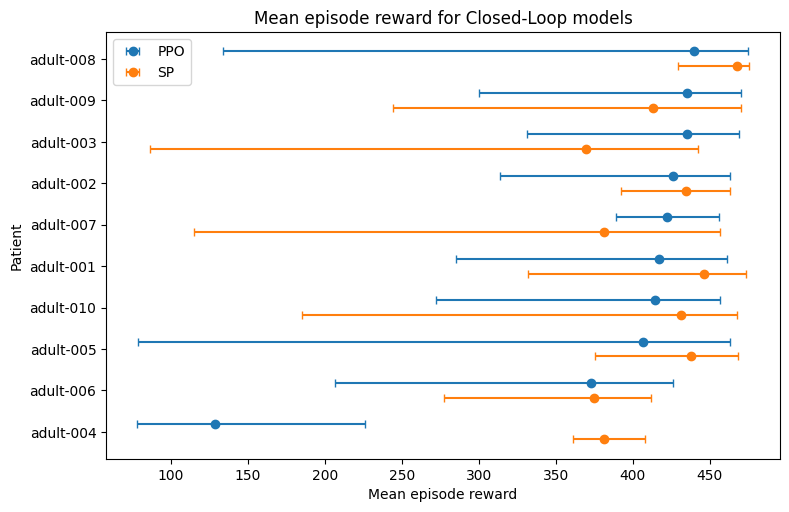

In [14]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = scores_df.sort_values(by="mean_reward_ppo").reset_index(drop=True)

y = np.arange(len(plot_df))
offset = 0.18

# Means
ppo_mean = plot_df["mean_reward_ppo"]
sp_mean = plot_df["mean_reward_sp"]

# Confidence bounds converted to asymmetric errors
ppo_xerr = np.vstack([
    ppo_mean - plot_df["reward_ti90_95_lower_ppo"],
    plot_df["reward_ti90_95_upper_ppo"] - ppo_mean
])

sp_xerr = np.vstack([
    sp_mean - plot_df["reward_ti90_95_lower_sp"],
    plot_df["reward_ti90_95_upper_sp"] - sp_mean
])

plt.figure(figsize=(8, max(5, 0.35 * len(plot_df))))

plt.errorbar(
    ppo_mean,
    y + offset,
    xerr=ppo_xerr,
    fmt="o",
    capsize=3,
    label="PPO"
)

plt.errorbar(
    sp_mean,
    y - offset,
    xerr=sp_xerr,
    fmt="o",
    capsize=3,
    label="SP"
)

plt.yticks(y, plot_df["patient"])
plt.xlabel("Mean episode reward")
plt.ylabel("Patient")
plt.legend()
#plt.grid(axis="y")
plt.tight_layout()
plt.title("Mean episode reward for Closed-Loop models")
plt.show()

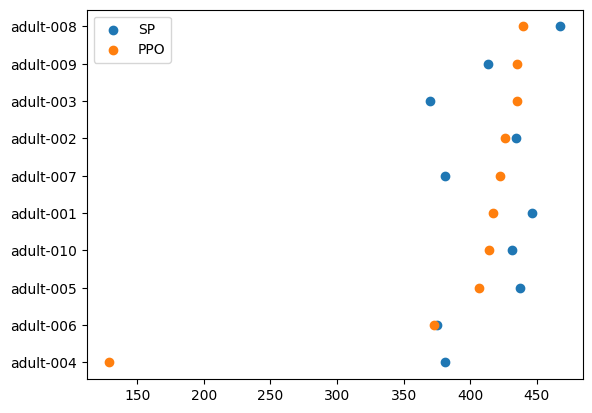

In [15]:
plot_df = scores_df.sort_values(by="mean_reward_ppo")
plt.scatter(plot_df["mean_reward_sp"], plot_df["patient"], label="SP")
plt.scatter(plot_df["mean_reward_ppo"], plot_df["patient"], label="PPO")
plt.legend()
#plt.grid()

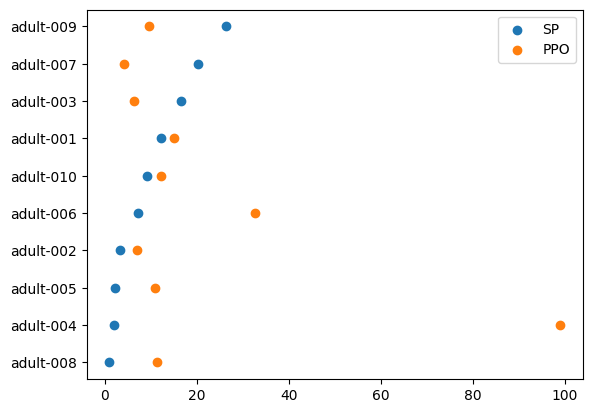

In [16]:
plot_df = scores_df.sort_values(by="critical_failure_rate_sp")
plt.scatter(plot_df["critical_failure_rate_sp"], plot_df["patient"], label="SP")
plt.scatter(plot_df["critical_failure_rate_ppo"], plot_df["patient"], label="PPO")
plt.legend()

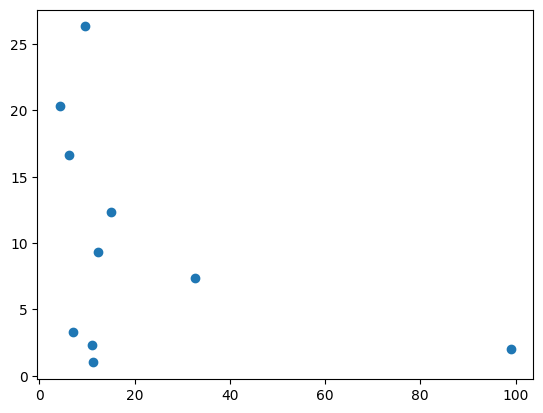

In [17]:
plt.scatter(plot_df["critical_failure_rate_ppo"], plot_df["critical_failure_rate_sp"], label="PPO")